# Safe Highway Overtaking with a Finite-State Machine

## 1. Requirement

The ego vehicle should drive on a multi-lane highway and perform an overtaking maneuver when a slower vehicle blocks its desired cruising behavior.

The vehicle should:

1. maintain a desired cruising speed when traffic permits,
2. detect a slower vehicle ahead,
3. evaluate adjacent lanes before changing lane,
4. change lane only when the target lane is sufficiently safe,
5. pass the slower vehicle,
6. return to an appropriate cruising lane after completing the overtake,
7. avoid collisions throughout the maneuver.

The first implementation uses the discrete behavior-level action space provided by Highway-env:

$$
\mathcal A=
\{
\text{LANE\_LEFT},
\text{IDLE},
\text{LANE\_RIGHT},
\text{FASTER},
\text{SLOWER}
\}.
$$

Thus, this notebook focuses on **behavior decision-making**, while Highway-env handles the underlying low-level steering and acceleration control.

## 2. Problem Decomposition

The overtaking problem can be decomposed into:

$$
\boxed{
\text{Observe traffic}
\rightarrow
\text{build traffic state}
\rightarrow
\text{decide behavior}
\rightarrow
\text{execute discrete action}
\rightarrow
\text{observe again}
}
$$

The decision-maker needs to answer:

1. Is there a slower vehicle ahead in the current lane?
2. Is overtaking necessary?
3. Which adjacent lane is a candidate?
4. Is the candidate lane safe to enter?
5. Has the ego vehicle passed the slower vehicle?
6. Is it safe to return to the cruising lane?

We implement this behavior using a **Finite-State Machine (FSM)**.

## 3. Finite-State Machine

The behavior planner uses the following states:

### CRUISE

The ego vehicle follows normal highway driving behavior.

If a slower vehicle ahead begins limiting progress, overtaking is considered.

### PREPARE_OVERTAKE

The ego evaluates candidate adjacent lanes.

If a safe and useful target lane is found, the overtaking maneuver begins.

If no safe lane is available, the ego remains in its lane and adapts its speed.

### CHANGE_LANE

The ego commands a lane change toward the selected overtaking lane.

The planner waits until the lane change is completed.

### PASS

The ego remains in the overtaking lane and passes the slower vehicle.

$$
\text{CRUISE}.
$$

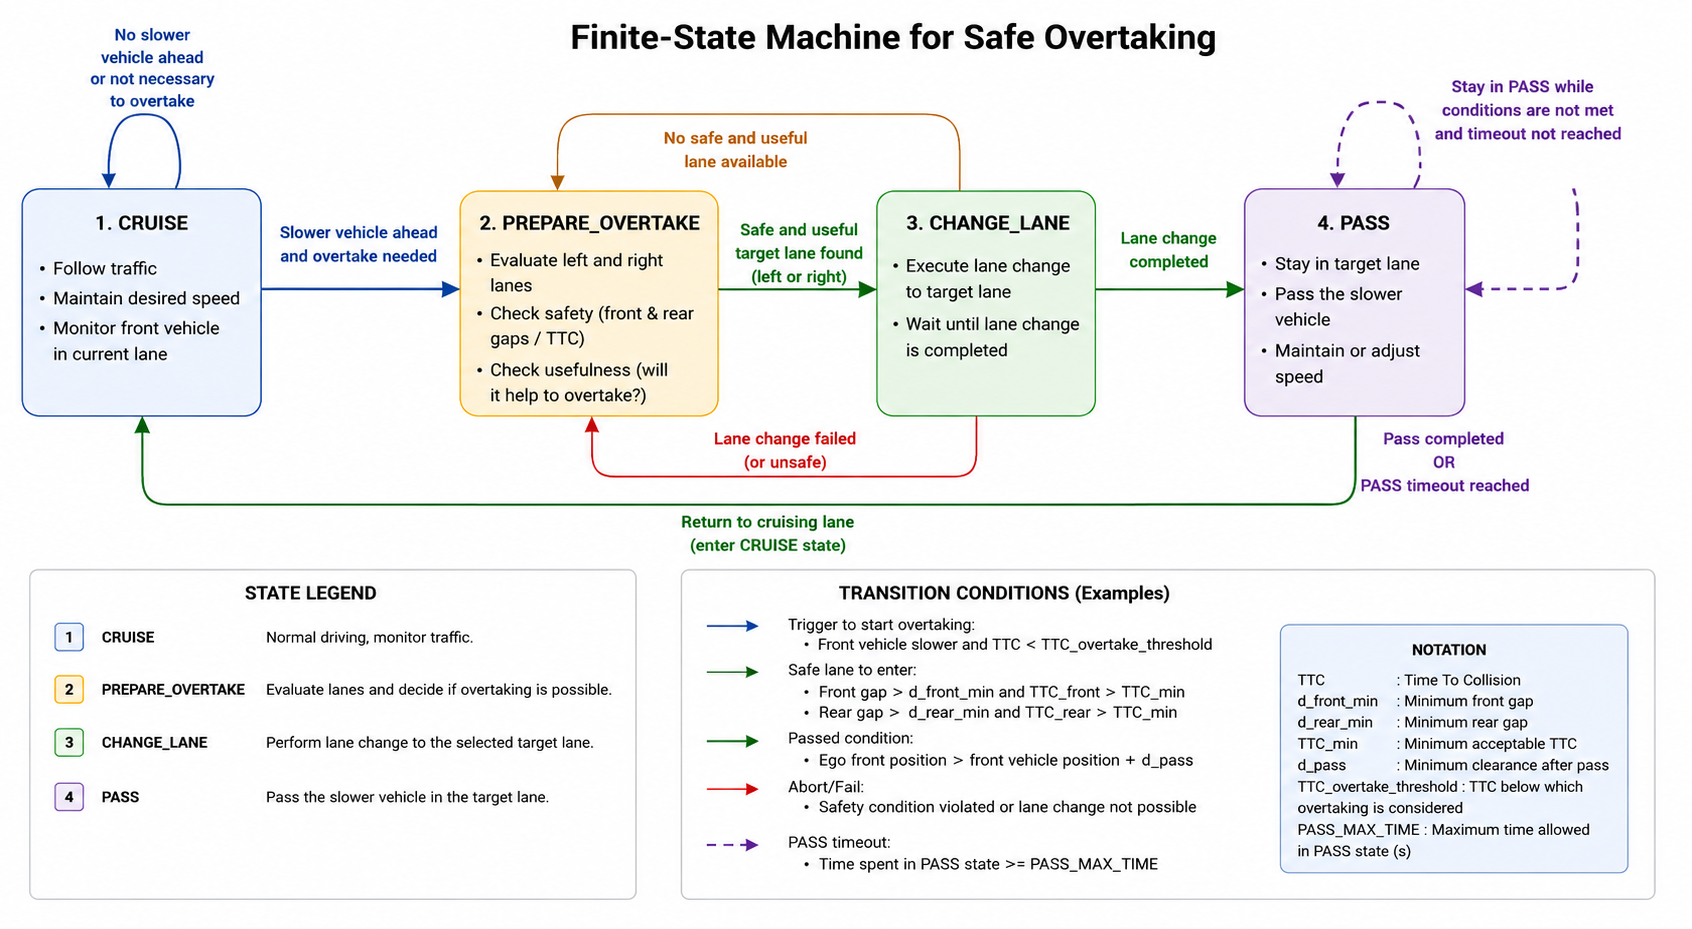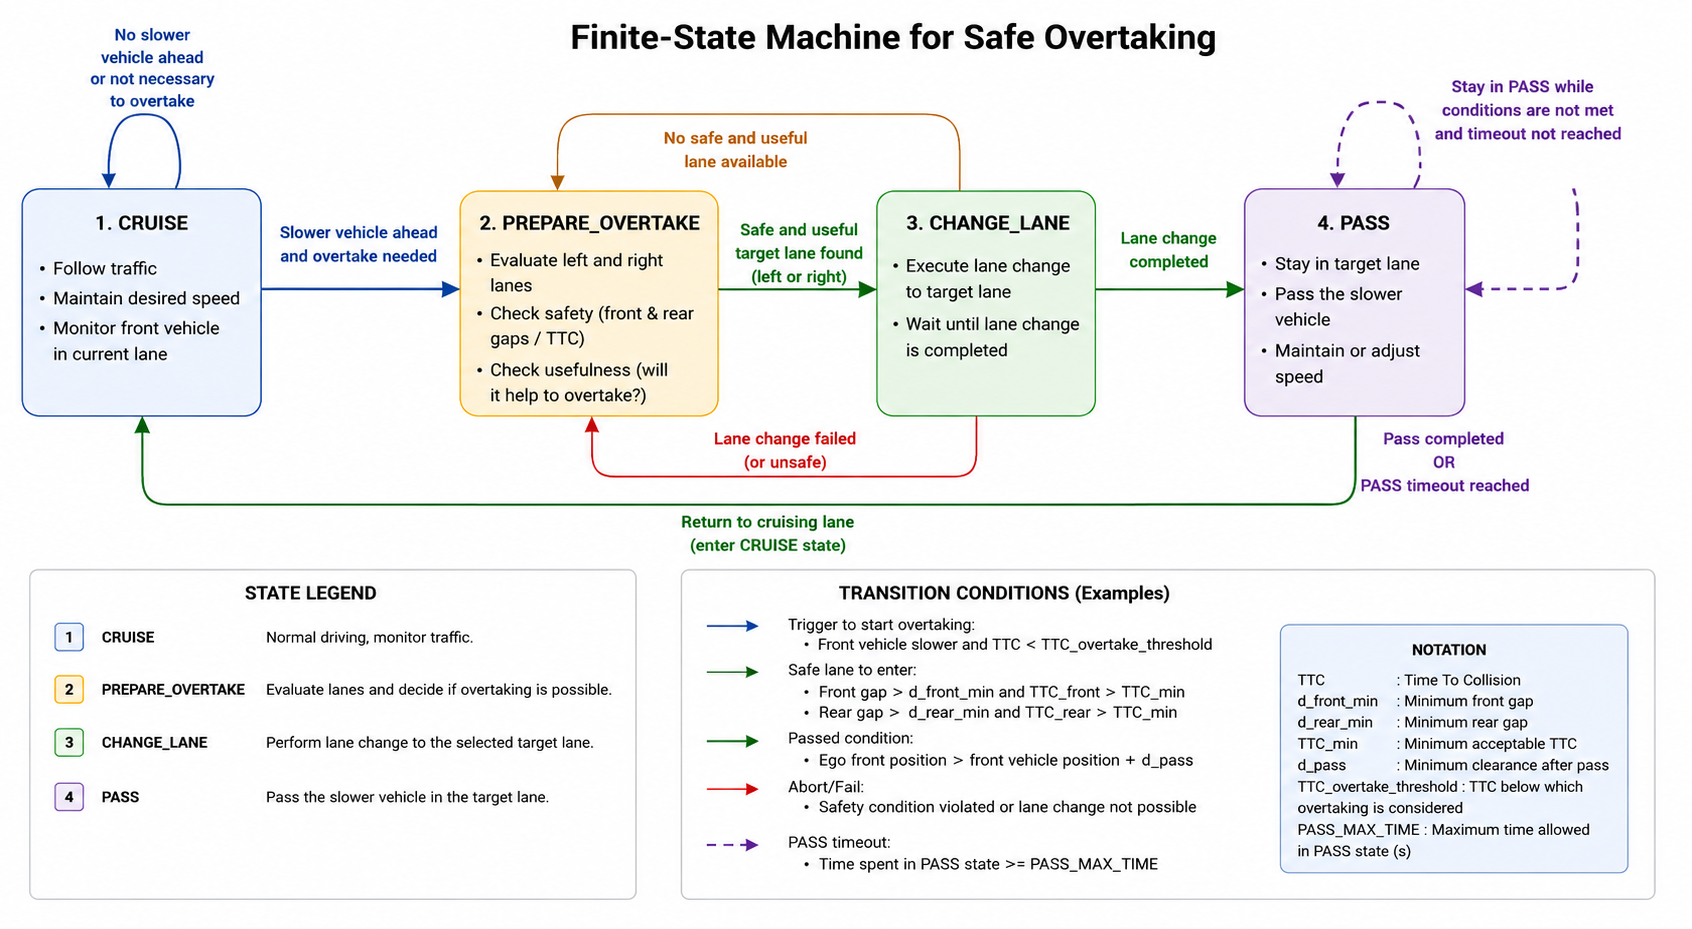

## 4. Traffic-State Representation

The Highway-env observation provides nearby vehicles as:

$$
o_i=
[
presence,\Delta x,\Delta y,\Delta v_x,\Delta v_y
].
$$

The FSM does not use the raw observation matrix directly.

Instead, we extract the nearest relevant vehicles in:

- the current lane,
- the adjacent left lane,
- the adjacent right lane.

For each lane we keep:

$$
\boxed{
\text{nearest front vehicle}
\quad\text{and}\quad
\text{nearest rear vehicle}
}
$$

with information such as:

$$
\Delta x,
\qquad
\Delta v_x.
$$

This produces a compact decision state:

$$
\boxed{
s_{\text{traffic}}=
\{
\text{current front/rear},
\text{left front/rear},
\text{right front/rear}
\}.
}
$$

In [84]:
import gymnasium as gym
import highway_env

import numpy as np
import matplotlib.pyplot as plt

from IPython.display import clear_output
from enum import Enum, auto

In [85]:
config = {
    "duration" :200,
    "observation": {
        "type": "Kinematics",
        "vehicles_count": 8,
        "features": [
            "presence",
            "x",
            "y",
            "vx",
            "vy"
        ],
        "absolute": False,
        "normalize": False
    }
}

env = gym.make(
    "highway-v0",
    render_mode="rgb_array",
    config=config
)

obs, info = env.reset(seed=42)

In [86]:
def relative_lane_offset(
    dy,
    lane_width=4.0,
    same_lane_tol=1.5
):
    if abs(dy) < same_lane_tol:
        return 0

    magnitude = int(
        np.ceil(abs(dy) / lane_width)
    )

    return magnitude if dy > 0 else -magnitude

In [87]:
def nearest_vehicles_in_lane(
    obs,
    lane_offset
):

    front = None
    rear = None

    for i, row in enumerate(obs[1:], start=1):

        presence, dx, dy, dvx, dvy = row

        if presence == 0:
            continue

        if relative_lane_offset(dy) != lane_offset:
            continue

        vehicle = {
            "id": i,
            "dx": float(dx),
            "dvx": float(dvx),
            "dy": float(dy),
            "dvy": float(dvy),
        }

        if dx > 0:
            if front is None or dx < front["dx"]:
                front = vehicle

        elif dx < 0:
            if rear is None or dx > rear["dx"]:
                rear = vehicle

    return front, rear

In [88]:
def build_traffic_state(obs):

    current_front, current_rear = (
        nearest_vehicles_in_lane(obs, 0)
    )

    left_front, left_rear = (
        nearest_vehicles_in_lane(obs, -1)
    )

    right_front, right_rear = (
        nearest_vehicles_in_lane(obs, +1)
    )

    return {
        "current": {
            "front": current_front,
            "rear": current_rear
        },
        "left": {
            "front": left_front,
            "rear": left_rear
        },
        "right": {
            "front": right_front,
            "rear": right_rear
        }
    }

In [89]:
traffic = build_traffic_state(obs)

traffic

{'current': {'front': None, 'rear': None},
 'left': {'front': None, 'rear': None},
 'right': {'front': {'id': 6,
   'dx': 126.58316040039062,
   'dvx': -1.7257367372512817,
   'dy': 4.0,
   'dvy': 0.0},
  'rear': None}}

## 5. Safety and Decision Metrics

The FSM uses a small set of derived traffic metrics rather than reasoning directly from the raw observation.

The main quantities are:

- longitudinal gap,
- relative longitudinal velocity,
- front Time-To-Collision,
- rear Time-To-Collision.

For a vehicle ahead:

$$
\Delta x > 0.
$$

If:

$$
\Delta v_x < 0,
$$

the ego vehicle is closing on the front vehicle.

The approximate front TTC is:

$$
\boxed{
TTC_{\text{front}}=
\frac{\Delta x}{-\Delta v_x}
}
$$

For a vehicle behind:

$$
\Delta x < 0.
$$

If:

$$
\Delta v_x > 0,
$$

the rear vehicle is approaching the ego vehicle.

The rear TTC is:

$$
\boxed{
TTC_{\text{rear}}=
\frac{-\Delta x}{\Delta v_x}.
}
$$

If there is no closing motion, TTC is treated as infinite.

In [90]:
def front_ttc(vehicle):
    if vehicle is None:
        return np.inf

    dx = vehicle["dx"]
    dvx = vehicle["dvx"]

    if dx > 0 and dvx < 0:
        return dx / (-dvx)

    return np.inf


def rear_ttc(vehicle):
    if vehicle is None:
        return np.inf

    dx = vehicle["dx"]
    dvx = vehicle["dvx"]

    if dx < 0 and dvx > 0:
        return (-dx) / dvx

    return np.inf

## 6. Behavior Parameters

The first FSM implementation uses simple heuristic thresholds.

These parameters determine when overtaking is considered and whether an adjacent lane is considered sufficiently safe.

They are design parameters rather than learned quantities.

In [91]:
# Overtaking trigger
OVERTAKE_GAP = 35.0          # m
OVERTAKE_TTC = 8.0           # s

# Target-lane safety
MIN_FRONT_GAP = 20.0         # m
MIN_REAR_GAP = 15.0          # m

MIN_FRONT_TTC = 5.0          # s
MIN_REAR_TTC = 5.0           # s

# Clearance before returning
PASS_CLEARANCE = 15.0        # m    

MAX_PASS_STEPS = 8

In [92]:
def overtake_needed(current_front):
    if current_front is None:
        return False

    gap = current_front["dx"]
    dvx = current_front["dvx"]

    # Ego must actually be catching the vehicle
    slower_vehicle = dvx < 0

    ttc = front_ttc(current_front)

    close_enough = gap < OVERTAKE_GAP
    ttc_low_enough = ttc < OVERTAKE_TTC

    return slower_vehicle and (
        close_enough or ttc_low_enough
    )

In [93]:
def lane_is_safe(front, rear):

    # -----------------
    # Front vehicle
    # -----------------

    if front is None:
        front_gap_safe = True
        front_ttc_safe = True

    else:
        front_gap_safe = (
            front["dx"] > MIN_FRONT_GAP
        )

        front_ttc_safe = (
            front_ttc(front) > MIN_FRONT_TTC
        )

    # -----------------
    # Rear vehicle
    # -----------------

    if rear is None:
        rear_gap_safe = True
        rear_ttc_safe = True

    else:
        rear_gap = -rear["dx"]

        rear_gap_safe = (
            rear_gap > MIN_REAR_GAP
        )

        rear_ttc_safe = (
            rear_ttc(rear) > MIN_REAR_TTC
        )

    return (
        front_gap_safe
        and front_ttc_safe
        and rear_gap_safe
        and rear_ttc_safe
    )

### Lane-Safety Condition

A candidate lane is considered safe when both the nearest front and rear vehicles satisfy minimum gap and TTC requirements.

Conceptually:

$$
\boxed{
\text{lane safe}=
\text{front safe}
\land
\text{rear safe}.
}
$$

The front vehicle is checked using:

$$
d_{\text{front}}
$$

and:

$$
TTC_{\text{front}}.
$$

The rear vehicle is checked using:

$$
d_{\text{rear}}
$$

and:

$$
TTC_{\text{rear}}.
$$

If no front or rear vehicle is observed in that lane, the corresponding condition is treated as safe.

In [94]:
traffic = build_traffic_state(obs)

current_front = traffic["current"]["front"]

print(
    "Overtake needed:",
    overtake_needed(current_front)
)

print(
    "Left lane safe:",
    lane_is_safe(
        traffic["left"]["front"],
        traffic["left"]["rear"]
    )
)

print(
    "Right lane safe:",
    lane_is_safe(
        traffic["right"]["front"],
        traffic["right"]["rear"]
    )
)

Overtake needed: False
Left lane safe: True
Right lane safe: True


In [95]:
def choose_overtaking_lane(
    traffic,
    available_actions
):

    # Try left lane first
    if ACTION_LANE_LEFT in available_actions:

        left_safe = lane_is_safe(
            traffic["left"]["front"],
            traffic["left"]["rear"]
        )

        if left_safe:
            return -1

    # Otherwise try right lane
    if ACTION_LANE_RIGHT in available_actions:

        right_safe = lane_is_safe(
            traffic["right"]["front"],
            traffic["right"]["rear"]
        )

        if right_safe:
            return +1

    return None

## 7. Target-Lane Usefulness

A lane can be safe to enter without being useful for overtaking.

Therefore, lane selection should satisfy two different conditions:

$$
\boxed{
\text{target lane safe}
}
$$

and:

$$
\boxed{
\text{target lane beneficial}.
}
$$

A simple first criterion is that the target lane should provide substantially more forward space than the current lane.

Thus, safe entry alone is not sufficient for an overtaking decision.

In [96]:
MIN_GAP_ADVANTAGE = 15.0  # m

In [97]:
def lane_is_beneficial(current_front, target_front):

    # Completely open target lane
    if target_front is None:
        return True

    # No blocker in current lane -> no reason to overtake
    if current_front is None:
        return False

    current_gap = current_front["dx"]
    target_gap = target_front["dx"]

    return (
        target_gap
        > current_gap + MIN_GAP_ADVANTAGE
    )

In [98]:
def choose_overtaking_lane(
    traffic,
    available_actions
):

    current_front = traffic["current"]["front"]

    # -------------------------
    # Left lane
    # -------------------------

    if ACTION_LANE_LEFT in available_actions:

        left_front = traffic["left"]["front"]
        left_rear = traffic["left"]["rear"]

        left_safe = lane_is_safe(
            left_front,
            left_rear
        )

        left_beneficial = lane_is_beneficial(
            current_front,
            left_front
        )

        if left_safe and left_beneficial:
            return -1

    # -------------------------
    # Right lane
    # -------------------------

    if ACTION_LANE_RIGHT in available_actions:

        right_front = traffic["right"]["front"]
        right_rear = traffic["right"]["rear"]

        right_safe = lane_is_safe(
            right_front,
            right_rear
        )

        right_beneficial = lane_is_beneficial(
            current_front,
            right_front
        )

        if right_safe and right_beneficial:
            return +1

    return None

### Aborting an Overtake

An overtaking attempt may become unnecessary before a suitable target lane becomes available.

For example, after slowing down:

$$
\Delta v_x \geq 0
$$

may indicate that the ego is no longer closing on the front vehicle.

Therefore:

$$
\boxed{
\text{PREPARE\_OVERTAKE}
\rightarrow
\text{CRUISE}
}
$$

when the overtaking trigger is no longer active.

In [99]:
DESIRED_SPEED = 25.0
RESUME_SPEED_GAP = 45.0

def cruise_action(env, traffic):

    ego_speed = env.unwrapped.vehicle.speed
    front = traffic["current"]["front"]

    # Completely free road
    if front is None:
        if ego_speed < DESIRED_SPEED - 1.0:
            return ACTION_FASTER

        return ACTION_IDLE

    # Front vehicle exists
    if (
        ego_speed < DESIRED_SPEED - 1.0
        and front["dx"] > RESUME_SPEED_GAP
    ):
        return ACTION_FASTER

    return ACTION_IDLE

### Hysteresis in Rule-Based Decisions

Using the same threshold for activating and releasing a behavior can cause repeated switching.

For example:

$$
d > d_{\text{threshold}}
\rightarrow
\text{accelerate}
$$

followed immediately by:

$$
d < d_{\text{threshold}}
\rightarrow
\text{slow down}.
$$

To avoid this, separate thresholds can be used:

$$
d_{\text{trigger}} < d_{\text{resume}}.
$$

This creates a hysteresis region and reduces oscillatory behavior.

In [100]:
def pass_completed(original_rear):

    if original_rear is None:
        return False

    rear_clearance = -original_rear["dx"]

    return rear_clearance > PASS_CLEARANCE

In [101]:
def pass_action(env, traffic):

    ego_speed = env.unwrapped.vehicle.speed
    front = traffic["current"]["front"]

    # No front vehicle: continue at desired speed
    if front is None:
        if ego_speed < DESIRED_SPEED - 1.0:
            return ACTION_FASTER
        return ACTION_IDLE

    # If we are closing too fast during the pass, slow down
    ttc = front_ttc(front)

    if (
        front["dx"] < MIN_FRONT_GAP
        or ttc < MIN_FRONT_TTC
    ):
        return ACTION_SLOWER

    # Otherwise maintain progress
    if ego_speed < DESIRED_SPEED - 1.0:
        return ACTION_FASTER

    return ACTION_IDLE

## 8. FSM State Definition

The overtaking planner maintains an internal behavior state.

This gives the planner memory of the maneuver that is currently being executed.

The states are:

$$
\boxed{
\text{CRUISE},
\text{PREPARE\_OVERTAKE},
\text{CHANGE\_LANE},
\text{PASS},
\text{RETURN}
}
$$

The FSM prevents the planner from making a completely new high-level decision at every timestep.

For example, once an overtaking maneuver has started, the planner remembers that it is currently passing another vehicle rather than immediately reconsidering the entire behavior.

In [102]:
class OvertakeState(Enum):
    CRUISE = auto()
    PREPARE_OVERTAKE = auto()
    CHANGE_LANE = auto()
    PASS = auto()
    RETURN = auto()

In [103]:
ACTION_LANE_LEFT = 0
ACTION_IDLE = 1
ACTION_LANE_RIGHT = 2
ACTION_FASTER = 3
ACTION_SLOWER = 4

In [104]:
class SafeOvertakingFSM:

    def __init__(self):

        self.state = OvertakeState.CRUISE

        self.original_lane = None
        self.target_lane = None
        self.overtaken_vehicle_id = None

        self.state_steps = 0

    def transition_to(self, new_state):
        self.state = new_state
        self.state_steps = 0

    def step(self, obs, env):

        traffic = build_traffic_state(obs)

        ego = env.unwrapped.vehicle
        current_lane = ego.lane_index[2]

        available_actions = (
            env.unwrapped.get_available_actions()
        )

        # -----------------------------------
        # CRUISE
        # -----------------------------------

        if self.state == OvertakeState.CRUISE:

            front = traffic["current"]["front"]

            if overtake_needed(front):

                self.transition_to(OvertakeState.PREPARE_OVERTAKE)

                self.original_lane = current_lane

            return cruise_action(
                    env,
                    traffic
                )


        # -----------------------------------
        # PREPARE OVERTAKE
        # -----------------------------------

        if self.state == OvertakeState.PREPARE_OVERTAKE:
            
            current_front = traffic["current"]["front"]

            # Overtaking is no longer necessary
            if not overtake_needed(current_front):
        
                self.transition_to(OvertakeState.CRUISE)
        
                self.original_lane = None
                self.target_lane = None
                self.overtaken_vehicle_id = None
        
                return cruise_action(
                    env,
                    traffic
                )

            lane_offset = choose_overtaking_lane(
                traffic,
                available_actions
            )

            # No safe lane available
            if lane_offset is None:
                return ACTION_SLOWER

            self.target_lane = (
                current_lane + lane_offset
            )

            self.transition_to(
                OvertakeState.CHANGE_LANE
            )

            if lane_offset == -1:
                return ACTION_LANE_LEFT

            else:
                return ACTION_LANE_RIGHT

        # -----------------------------------
        # CHANGE LANE
        # -----------------------------------
        
        if self.state == OvertakeState.CHANGE_LANE:
        
            # Target lane reached
            if current_lane == self.target_lane:
        
                self.transition_to(OvertakeState.PASS)
        
                return ACTION_IDLE
        
            # Lane change still in progress
            return ACTION_IDLE
            
        # -----------------------------------
        # PASS
        # -----------------------------------
        
        if self.state == OvertakeState.PASS:

            original_offset = (
                self.original_lane - current_lane
            )
        
            _, original_rear = nearest_vehicles_in_lane(
                obs,
                original_offset
            )
        
            completed = pass_completed(
                original_rear
            )
        
            timeout = (
                self.state_steps >= MAX_PASS_STEPS
            )
        
            if completed or timeout:
        
                self.transition_to(
                    OvertakeState.CRUISE
                )
        
                self.original_lane = None
                self.target_lane = None
        
                return ACTION_IDLE
        
            return pass_action(
                env,
                traffic
            )


        return ACTION_IDLE

## 9. Testing the Initial FSM Transitions

Before implementing the complete overtaking maneuver, we test the currently available transitions:

$$
\text{CRUISE}
\rightarrow
\text{PREPARE\_OVERTAKE}
\rightarrow
\text{CHANGE\_LANE}.
$$

At every timestep we monitor:

- FSM state,
- selected action,
- ego lane,
- nearest front-vehicle gap,
- collision status.

This allows us to verify the behavior incrementally before adding the remaining states.

In [105]:
ACTION_NAMES = {
    ACTION_LANE_LEFT: "LANE_LEFT",
    ACTION_IDLE: "IDLE",
    ACTION_LANE_RIGHT: "LANE_RIGHT",
    ACTION_FASTER: "FASTER",
    ACTION_SLOWER: "SLOWER",
}

In [111]:
obs, info = env.reset()

planner = SafeOvertakingFSM()

history = []
frames = []

# Initial frame
frames.append(env.render())

In [112]:
for t in range(200):

    # Current traffic state
    traffic = build_traffic_state(obs)

    current_front = traffic["current"]["front"]

    if current_front is None:
        front_gap = np.inf
        front_ttc_value = np.inf
    else:
        front_gap = current_front["dx"]
        front_ttc_value = front_ttc(current_front)

    # FSM decision
    state_before = planner.state

    planner.state_steps += 1
    action = planner.step(
        obs,
        env
    )

    state_after = planner.state

    ego = env.unwrapped.vehicle

    # Execute selected action
    obs, reward, terminated, truncated, info = env.step(
        action
    )
    frames.append(env.render())

    history.append({
        "step": t,
        "state_before": state_before.name,
        "state_after": state_after.name,
        "action": ACTION_NAMES[action],
        "lane": ego.lane_index[2],
        "front_gap": front_gap,
        "front_ttc": front_ttc_value,
        "speed": ego.speed,
        "crashed": info["crashed"],
        "step_count": planner.state_steps
    })

    if terminated or truncated:
        break

In [113]:
import imageio.v2 as imageio
#%pip install "imageio[ffmpeg]"

In [114]:
video_path = "safe_overtaking_fsm.mp4"

imageio.mimsave(
    video_path,
    frames,
    fps=5
)

IMAGEIO FFMPEG_WRITER WARNING: input image is not divisible by macro_block_size=16, resizing from (600, 150) to (608, 160) to ensure video compatibility with most codecs and players. To prevent resizing, make your input image divisible by the macro_block_size or set the macro_block_size to 1 (risking incompatibility).


In [115]:
from IPython.display import Video

Video(
    video_path,
    embed=True,
    width=800
)

In [79]:
for row in history:

    gap_text = (
        f"{row['front_gap']:.1f} m"
        if np.isfinite(row["front_gap"])
        else "-"
    )

    ttc_text = (
        f"{row['front_ttc']:.1f} s"
        if np.isfinite(row["front_ttc"])
        else "-"
    )

    print(
        f"step={row['step']:2d} | "
        f"{row['state_before']:18s} -> "
        f"{row['state_after']:18s} | "
        f"action={row['action']:10s} | "
        f"lane={row['lane']} | "
        f"speed={row['speed']:5.1f} | "
        f"gap={gap_text:8s} | "
        f"TTC={ttc_text:7s} | "
        f"crashed={row['crashed']} | "
        f"step_count={row['step_count']}"
    )

step= 0 | CRUISE             -> CRUISE             | action=IDLE       | lane=0 | speed= 25.0 | gap=-        | TTC=-       | crashed=False | step_count=1
step= 1 | CRUISE             -> CRUISE             | action=IDLE       | lane=0 | speed= 25.0 | gap=-        | TTC=-       | crashed=False | step_count=2
step= 2 | CRUISE             -> CRUISE             | action=IDLE       | lane=0 | speed= 25.0 | gap=117.8 m  | TTC=24.9 s  | crashed=False | step_count=3
step= 3 | CRUISE             -> CRUISE             | action=IDLE       | lane=0 | speed= 25.0 | gap=113.2 m  | TTC=25.4 s  | crashed=False | step_count=4
step= 4 | CRUISE             -> CRUISE             | action=IDLE       | lane=0 | speed= 25.0 | gap=108.8 m  | TTC=25.6 s  | crashed=False | step_count=5
step= 5 | CRUISE             -> CRUISE             | action=IDLE       | lane=0 | speed= 25.0 | gap=104.7 m  | TTC=25.8 s  | crashed=False | step_count=6
step= 6 | CRUISE             -> CRUISE             | action=IDLE       | lan

## Takeaway

This notebook implemented a rule-based highway overtaking behavior planner using a Finite State Machine (FSM).

The complete pipeline was:

Observation
→ Traffic-state extraction
→ Safety metrics
→ Behavior decision
→ Discrete action

The FSM used the states:

CRUISE
→ PREPARE_OVERTAKE
→ CHANGE_LANE
→ PASS
→ CRUISE

The experiment demonstrated that even a seemingly simple behavior such as overtaking requires reasoning about:

- relative position and velocity,
- front and rear gaps,
- time-to-collision,
- adjacent-lane safety,
- usefulness of a lane change,
- longitudinal safety during the maneuver,
- abort/recovery conditions,
- hysteresis,
- and temporal state persistence.

The FSM provides an interpretable and deterministic solution, but its behavior depends on manually designed rules and thresholds.

This motivates decision-making approaches that can reason over future outcomes, optimize behavior, or learn policies from interaction.